In [1]:
import numpy as np
import scipy.stats as st
import sklearn.linear_model as lm
import matplotlib.pyplot as plt
import pandas as pd
from io import StringIO
%matplotlib inline
import time

import h5py 
import os

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import statsmodels
import seaborn as sns
# import bioinfokit
from sklearn.model_selection import LeaveOneGroupOut
logo = LeaveOneGroupOut()
import pickle

In [2]:
%run classifiers_functions.ipynb

# Import training data & train model

# Import test data & predict using model(s)

In [31]:
# list all csv file in folder
from os import listdir
 
def list_files(directory, extension):
    return (f for f in listdir(directory) if f.endswith('.' + extension))

# directory = "E:/HyReS/results/DS brains/Images for clf/HyReS h5/"
directory = "E:/HyReS/results/DS brains/independent prediction/HyReS/"
files = list_files(directory, "h5")
filenames=[]
for f in files:
    filenames.append(f)

print(len(filenames))    
filenames

2


['datacube_HyReS.h5', 'hrmask5.h5']

In [32]:
filename = filenames[0]
with h5py.File(directory+filename, "r") as f:
    # List all groups
    print("Keys: %s" % f.keys())
    a_group_key = list(f.keys())[0]

h5 = h5py.File(directory+filename,'r')
# Get the data
datacube = h5.get('datacube')
dims = h5.get('dims')
mz = h5.get('mz')
mz = np.array(mz)

Keys: <KeysViewHDF5 ['datacube', 'dims', 'mz']>


# Load classification features

In [19]:
features = pickle.load(open('E:/HyReS/results/DS brains/selected_features_hyres_enh.pkl', 'rb'))
# features = pd.read_csv('E:/HyReS/results/DS brains/features.csv').values

threshold = 100
indices = [None]*len(features)
for j in range (0,len(features)):
#             print(j)
    try:
        index = np.argmin(abs((mz)-float(features[j])))
        if (mz[index]-float(features[j]))/float(features[j])*(10^6) <= threshold:
            indices[j] = (index)
    except:
        indices[j] = (0)
        
# indices
mz = mz[indices]

In [33]:
%%time
datacube = np.transpose(datacube)
# datacube = datacube[:,indices]

datacube.shape

CPU times: total: 19.2 s
Wall time: 3min 54s


(1458240, 1717)

# Load saved model

In [21]:
loaded_model = pickle.load(open('E:/HyReS/results/DS brains/Trained_models/trained_SVM_HyReS.sav', 'rb'))
loaded_model

SVC(class_weight={'Normal': 1.0, 'Trisomic': 0.978681063188383},
    decision_function_shape='ovo', kernel='linear', probability=True)

# Normalise and predict

In [22]:
%%time

Data_test_n = data_norm(datacube, method='tic')
Data_test_log = data_norm(Data_test_n, method='log')

C:\Users\yx2011\AppData\Local\Temp\ipykernel_32468\102887883.py:20: RuntimeWarning: invalid value encountered in divide
  Data_TIC[i] = data[i]/np.sum(data[i])


CPU times: total: 47.2 s
Wall time: 47.3 s


In [23]:
%%time

# Data_test_log = np.transpose(Data_test_log)
test_results = loaded_model.predict_proba(Data_test_log)

CPU times: total: 2h 28min 14s
Wall time: 2h 28min 25s


In [40]:
print(test_results)
probs_out = pd.DataFrame(data=test_results,columns = ['Trisomic','Normal'])
probs_out.to_csv (r'E:/HyReS/results/DS brains/pred_probs_enh_indep.csv', index = False, header=True)

[[3.0000009e-14 1.0000000e+00]
 [3.0000009e-14 1.0000000e+00]
 [3.0000009e-14 1.0000000e+00]
 ...
 [3.0000009e-14 1.0000000e+00]
 [3.0000009e-14 1.0000000e+00]
 [3.0000009e-14 1.0000000e+00]]


# Quick visualisation

## Ion image

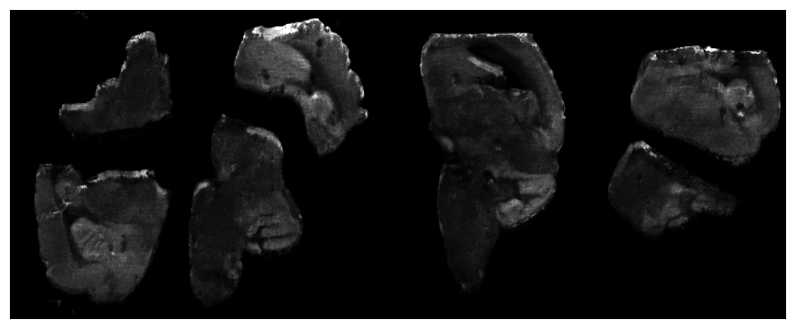

In [107]:
ion = 885.5
index= np.argmin(abs(np.array(mz)-ion))
ion_image = datacube[:,index]
ion_image = ion_image.reshape((int(dims[1]),int(dims[0])))
fig, ax = plt.subplots()
im = ax.imshow(ion_image*mask,cmap = 'gray', aspect='auto',vmax = 1e5)
fig.set_size_inches(10, 4)
# fig.colorbar(im)
# plt.show()
plt.tick_params(left = False, right = False , labelleft = False , 
                labelbottom = False, bottom = False) 
# fig.colorbar(im)
# plt.show()
plt.savefig('ion.png',bbox_inches='tight',dpi=120)

## Mask

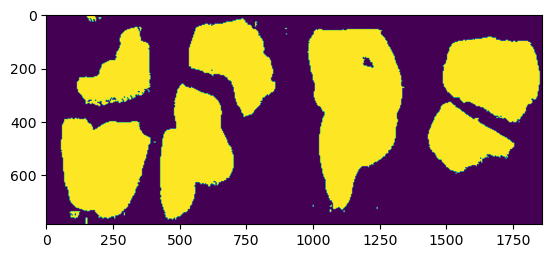

In [35]:
maskname = 'E:/HyReS/results/DS brains/independent prediction/HYRES/hrmask5.h5'
# maskname = 'E:/HyReS/results/DS brains/Images for clf/HyReS h5/masks/hrmask2.h5'

maskh5 = h5py.File(maskname,'r')

mask = maskh5.get('mask')
# mask = np.array(mask, dtype=bool)
mask = np.transpose(mask)
fig, ax = plt.subplots()
im = ax.imshow(mask)
# fig.set_size_inches(5, 10)
plt.show()

# Prediction image

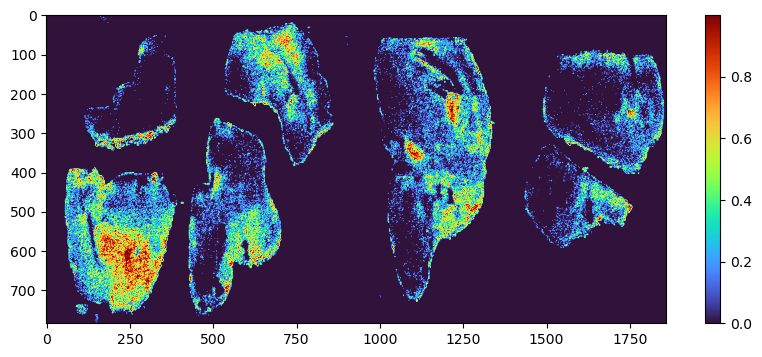

In [41]:
# test = test_results[:,0]
# test.shape
pred_image = test_results[:,0].reshape((int(dims[1]),int(dims[0])))
fig, ax = plt.subplots()
im = ax.imshow(pred_image*mask,cmap = 'turbo', aspect='auto')
fig.set_size_inches(10, 4)
fig.colorbar(im)
plt.show()

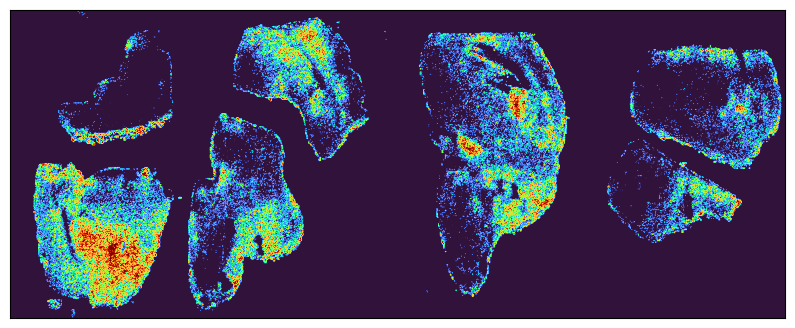

In [77]:
fig, ax = plt.subplots()
im = ax.imshow(pred_image[:,:,1],cmap = 'turbo', aspect='auto')
plt.tick_params(left = False, right = False , labelleft = False , 
                labelbottom = False, bottom = False) 
fig.set_size_inches(10, 4)
# fig.colorbar(im)
# plt.show()
plt.savefig('pred.png',bbox_inches='tight',dpi=120)
# pred_image.shape

# Overlay

In [115]:
import cv2
# fig, ax = plt.subplots()
# im = ax.imshow(ion_image*mask,cmap = 'gray',vmax = 1e5)
# fig.set_size_inches(10, 5)
# fig.colorbar(im)
# plt.show()

# back_image = np.zeros((ion_image.shape[0], ion_image.shape[1], 3), np.uint8)
# back_image[:, :, 0] = ion_image*mask/np.max(ion_image)*255
# back_image[:, :, 1] = ion_image*mask/np.max(ion_image)*255
# back_image[:, :, 2] = ion_image*mask/np.max(ion_image)*255

back_image = cv2.imread('ion.png')

# prediction = pd.read_csv('E:/HyReS/results/DS brains/pred_probs_enh_indep.csv').values
# prediction = prediction[:,0].reshape((int(dims[1]),int(dims[0])))
# fig, ax = plt.subplots()
# im = ax.imshow(pred_image*mask,cmap = 'turbo', aspect='auto')
# fig.set_size_inches(10, 4)
# fig.colorbar(im)
# plt.show()
# pred_image = np.zeros((int(dims[1]),int(dims[0]), 3), np.uint8)
# pred_image[:, :, 0] = prediction*mask*255
# pred_image[:, :, 1] = prediction*mask*255
# pred_image[:, :, 2] = prediction*mask*255

heatmap = cv2.imread('pred.png')
# heatmap = cv2.resize(heatmap, (back_image.shape[1], back_image.shape[0]))

# heatmap = cv2.applyColorMap(pred_image, cv2.COLORMAP_TURBO)
# cv2.imshow('Grayscale', back_image)
# cv2.imshow('Prediction map', heatmap)


overlay = cv2.addWeighted(back_image,1,heatmap,0.6,0)
# cv2.imshow('Overlay', overlay)
# cv2.waitKey(0)   
cv2.imwrite('D:/BOX/Box Sync/Publications/HyReS/figures/tissue_overlay2.png', overlay)
# Window shown waits for any key pressing event 
# cv2.destroyAllWindows()

True

# Plot CM & ROC curves

In [7]:
CM = pd.read_csv('E:/HyReS/results/DS brains/cm1_indp.csv').values
ROCs = pd.read_csv('E:/HyReS/results/DS brains/ROCs.csv')
ROCs

,FPR1,TPR1,FPR2,TPR2,FPR3,TPR3,FPR4,TPR4
0,0.00,0.000,0.000,0.000,0.0,0.0,0.0,0.0
1,0.00,0.500,0.000,0.625,0.0,0.0,0.0,0.5
2,0.00,0.500,0.125,0.625,0.0,0.0,0.0,0.5
3,0.50,0.500,0.250,0.625,0.5,0.5,0.0,0.5
4,0.50,0.500,0.250,0.875,0.5,0.5,0.0,0.5
5,0.50,0.500,0.250,0.875,0.5,0.5,0.0,0.5
6,0.50,0.750,0.500,1.000,0.5,0.5,0.0,0.5
7,0.50,0.875,0.625,1.000,0.5,0.5,0.0,0.5
8,0.75,0.875,0.875,1.000,1.0,1.0,0.0,0.5
9,0.75,0.875,1.000,1.000,1.0,1.0,0.5,1.0


In [8]:
cmlabels = ['Monosomic','Trisomic']
performance = calculate_FPASS (CM,cmlabels)
performance

C:\Users\yx2011\AppData\Local\Temp\ipykernel_25272\2551593479.py:12: RuntimeWarning: invalid value encountered in scalar divide
  results.iloc[i,2] = (TP)/(TP+FN)
C:\Users\yx2011\AppData\Local\Temp\ipykernel_25272\2551593479.py:13: RuntimeWarning: invalid value encountered in scalar divide
  results.iloc[i,3] = (TN)/(TN+FP)


,class,accuracy,sensitivity,specificity,precision,F1
0,Monosomic,NaN,NaN,0.5,0.0,0.0
1,Trisomic,NaN,0.5,NaN,1.0,0.666667
2,Average,NaN,0.5,0.5,0.5,0.333333


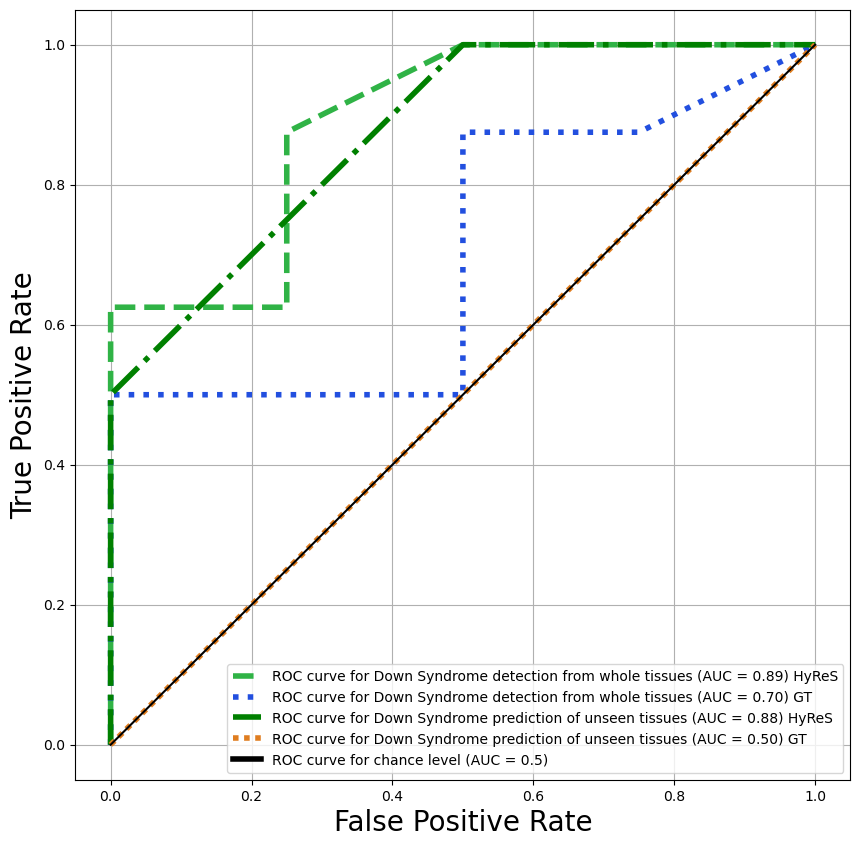

In [37]:
plt.figure(1, figsize=(10,10))
plt.plot(
    ROCs['FPR2'],
    ROCs['TPR2'],
    label='ROC curve for %s detection from whole tissues (AUC = %0.2f) HyReS' % (cmlabels[1], 0.89),
    color="#30b346",
    linestyle='dashed',
    linewidth=4,
)
plt.plot(
    ROCs['FPR1'],
    ROCs['TPR1'],
    label='ROC curve for %s detection from whole tissues (AUC = %0.2f) GT' % (cmlabels[1], 0.70),
    color="#224fdf",
    linestyle='dotted',
    linewidth=4,
)
plt.plot(
    ROCs['FPR4'],
    ROCs['TPR4'],
    label='ROC curve for %s prediction of unseen tissues (AUC = %0.2f) HyReS' % (cmlabels[1], 0.88),
    color="g",
    linestyle='dashdot',
    linewidth=4,
)
plt.plot(
    ROCs['FPR3'],
    ROCs['TPR3'],
    label='ROC curve for %s prediction of unseen tissues (AUC = %0.2f) GT' % (cmlabels[1], 0.5),
    color="#df7d20",
    linestyle=((0,(1,1))),
    linewidth=4,
)
plt.plot([0, 1], [0, 1], "k-", label="ROC curve for chance level (AUC = 0.5)")
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate',fontsize=20)
plt.ylabel('True Positive Rate',fontsize=20)
leg = plt.legend(loc="lower right")
leg_lines = leg.get_lines()
leg_texts = leg.get_texts()
plt.setp(leg_lines, linewidth=4)
# plt.setp(leg_texts, fontsize='x-large')
plt.grid()
plt.savefig("D:/BOX/Box Sync/Publications/HyReS/figures/DS_ROCs.pdf", format="pdf", bbox_inches="tight")
plt.show()

# Randomly re-sample positive/negative to balance

In [4]:
# from sklearn.utils.random import sample_without_replacement as resample

# positives = (file['Label'] == 'Positive')
# positives = file[positives]
# negatives = (file['Label'] == 'Negative')
# negatives = file[negatives]

# # sample_50pos = resample (n_population=(len(positives)),n_samples=50)
# # sample_50pos = positives
# sample_50neg = resample (n_population=(len(negatives)),n_samples=68)

# data_pos = positives
# data_neg = negatives.iloc[sample_50neg,:]

# frames=[data_pos, data_neg]
# file_resample= pd.concat(frames)
# Data_resample = file_resample.iloc[:,2:226]
# # Data_resample = pd.concat(frames)
# label = file_resample['Label'].tolist()

# Data = Data_resample
# Data

In [14]:
# list all csv file in folder
from os import listdir
 
def list_files(directory, extension):
    return (f for f in listdir(directory) if f.endswith('.' + extension))

directory = "D:/BOX/Box Sync/RA/data/IMAGING/DESI/CRUK/pik3ca/Preprocessed/dipas_neg/CSV/"
files = list_files(directory, "csv")
filenames=[]
for f in files:
    filenames.append(f)

print(len(filenames))    
filenames

56


['0602038A1_neg.csv',
 '0802085B_neg.csv',
 '0802086A_neg.csv',
 '0802157_A1_neg.csv',
 '0802182_A2_neg.csv',
 '0802186A_neg.csv',
 '0802196_A1_B_neg.csv',
 '0802196_A2_B_neg.csv',
 '0902110 B2_R_neg.csv',
 '0902110B_neg.csv',
 '0902196_A_neg.csv',
 '102077_B1_neg.csv',
 '102077_B2_T_neg.csv',
 '102100_A1_neg.csv',
 '102100_A2_T_neg.csv',
 '1102013A3_neg.csv',
 '1102047A1_neg.csv',
 '1102052A_neg.csv',
 '1102103A_neg.csv',
 '1102119A1_neg.csv',
 '1102131A_neg.csv',
 'CX12000052_FT10_neg.csv',
 'CX12000060_FT11_neg.csv',
 'CX12000070_FT4_neg.csv',
 'CX12000102_FT2_neg.csv',
 'CX12000149_FT3_T_neg.csv',
 'CX12000253_FT1_neg.csv',
 'CX12000253_FT2_neg.csv',
 'CX1200044_FT4_neg.csv',
 'CX1200044_FT6_neg.csv',
 'CX1200060_FT12_T_neg.csv',
 'CX1200070_FT8_neg.csv',
 'CX1200200_FT11_2T_neg.csv',
 'CX1200200_FT3_neg.csv',
 'CX1200208_FT2_T_neg.csv',
 'CX13000012_FT2_neg.csv',
 'CX13000027_FT3_neg.csv',
 'CX13000072_FT12_neg.csv',
 'CX13000076_FT3_B_neg.csv',
 'CX13000080_FT1_neg.csv',
 'CX1300

In [34]:
label = file['Label'].tolist()

for k in range (0,len(filenames)):
    print(k)
    test_file = pd.read_csv(directory+filenames[k])
    common_mz = list(test_file.columns) 
    # common_mz
    test_data = test_file.iloc[:,:]
    mz_ind = np.zeros(len(common_mz))
    for i in range (0, len(common_mz)):
        mz_ind[i] = np.argmin(abs(mz-float(common_mz[i])))
        mz_ind[i] = int(mz_ind[i])

    print(test_data.shape)
    
    
    Data_r=np.zeros((len(Data),len(common_mz)))
    for n in range (0,len(common_mz)):
        Data_r[:,n]=file.iloc[:, int(mz_ind[n])]
    # for n in range (0,len(features_lasso)):
    #     Data_r[:,n]=file.iloc[:,str(features_lasso[n])]

    tmp_log = Data_r[Data_r != 0]
    logOS = np.nanmedian(tmp_log)
    Data_r_log = np.log(Data_r+logOS)
    # Data_r_log.shape
    print(Data_r.shape)

# CV to check model with common_mz
#     model_r = LogisticRegression(solver='liblinear',class_weight=weights)
#     cvFold = logo.split(Data_r_log,label,groups=file['ID'])
#     # cvFold = logo.split(Data_r, file.iloc[:,1],label)
#     cv_results3 = cross_val_score(model_r, Data_r_log, label, cv=cvFold)
#     cm3 = calculate_cm(cv_results3,file.iloc[:,1])
#     sen3 = (cm3[0,0])/(cm3[0,0]+cm3[0,1])*100
#     spec3 = (cm3[1,1])/(cm3[1,1]+cm3[1,0])*100
#     print('with LOOCV, classification accuracy with these features:\n')
#     print('confusion matrix = ')
#     print(cm3, '\n')
#     print('accuracy = ',cv_results3.mean()*100, '%','\n')
#     print('sensitivity = TP / (TP+FN) = ',sen3, '%','\n')
#     print('specificity = TN / (TN+FP) = ',spec3, '%','\n')
    
# tidy up & save results

    tmp_log = test_data[test_data != 0]
    logOS = np.nanmedian(tmp_log)
    Data_test_log = np.log(test_data+logOS)
    # Data_r_log.shape

    LR_model = LogisticRegression(solver='liblinear',class_weight=weights)
    LR_model.fit(Data_r_log, label)
    prediction = LR_model.predict(Data_test_log)

    class1 = (prediction == 'WT')
    class2 = (prediction == 'PIK3CA')
    prediction[class1] = 1
    prediction[class2] = 2
    prediction=np.reshape(prediction,(-1,1))
    test = np.zeros(len(prediction))
    for m in range (1,len(prediction)):
        test[m] = float(prediction[m])
    
    savename = filenames[k][:-4]
    savepath = "D:/BOX/Box Sync/RA/data/IMAGING/DESI/CRUK/pik3ca/prediction/"
    np.savetxt((savepath+savename+'.txt'),test,delimiter=',') 

0
(9680, 154)
(496, 154)
1
(16768, 112)
(496, 112)
2
(11280, 89)
(496, 89)
3
(11921, 205)
(496, 205)
4
(11830, 60)
(496, 60)
5
(9191, 83)
(496, 83)
6
(7371, 117)
(496, 117)
7
(8080, 66)
(496, 66)
8
(18281, 76)
(496, 76)
9
(10010, 69)
(496, 69)
10
(13431, 129)
(496, 129)
11
(15651, 153)
(496, 153)
12
(5670, 120)
(496, 120)
13
(12221, 104)
(496, 104)
14
(14410, 146)
(496, 146)
15
(6080, 61)
(496, 61)
16
(11011, 117)
(496, 117)
17
(12831, 79)
(496, 79)
18
(12231, 176)
(496, 176)
19
(5700, 121)
(496, 121)
20
(9680, 174)
(496, 174)
21
(15100, 79)
(496, 79)
22
(13041, 39)
(496, 39)
23
(11921, 72)
(496, 72)
24
(6060, 87)
(496, 87)
25
(5680, 103)
(496, 103)
26
(8100, 72)
(496, 72)
27
(6710, 74)
(496, 74)
28
(10611, 59)
(496, 59)
29
(6461, 112)
(496, 112)
30
(8591, 84)
(496, 84)
31
(7280, 58)
(496, 58)
32
(5680, 102)
(496, 102)
33
(11100, 86)
(496, 86)
34
(9373, 133)
(496, 133)
35
(5551, 82)
(496, 82)
36
(7280, 99)
(496, 99)
37
(7280, 168)
(496, 168)
38
(7371, 105)
(496, 105)
39
(7381, 70)
(496

In [430]:
RF_model = RandomForestClassifier(n_estimators= num_trees, max_features=max_features)
RF_model.fit(Data_log, label)
prediction2 = RF_model.predict(Data_log_test)

In [402]:
LDA_model = LinearDiscriminantAnalysis()
LDA_model.fit(Data_log, label)
prediction3 = LDA_model.predict(Data_log_test)

# Various feature selection approaches for LR

In [416]:
importance_LR=np.abs(clf2.coef_)
# importance_LR[idx_features]
# importance_LR=np.reshape(importance_LR,(5792, 2))

# idx_features1 = importance_LR[:,0].argsort()[:50]
# idx_features2 = importance_LR[:,1].argsort()[:50] #KRAS_SIM vs everything else
# idx_features3 = importance_LR[:,2].argsort()[:50]
# idx_features4 = importance_LR[:,3].argsort()[:50]
# idx_features2
# features_LR=mz[idx_features2]
# features_LR=np.reshape(features_LR,(50,1))
# plt.plot(mz,importance_LR[:,0])
importance_LR
# features_LR
# np.savetxt('D:/BOX/Box Sync/RA/data/IMAGING/DESI/CRUK/project E/features_LR.txt',features_LR,delimiter=',')

array([[0.37335715]])

In [437]:
importance_LR=np.abs(LR_model.fit(Data_log,label).coef_)
importance_LR=np.reshape(importance_LR,(len(mz), 1))
# plt.plot(mz,importance_LR)

#function to evaluate significance of each regression coefficient in model
#*direct ranking of coefficient values is less intuitive in LR, since they represent change 
# in the LOGIT for each unit change in a particular m/z value
def logit_pvalue(model, x):
    """ Calculate z-scores for scikit-learn LogisticRegression.
    parameters:
        model: fitted sklearn.linear_model.LogisticRegression
        x:     matrix on which the model was fit
    This function uses asymtptics for maximum likelihood estimates.
    """
    p = model.predict_proba(x)
    n = len(p)
    m = len(model.coef_[0])+1
    coefs = np.concatenate([model.intercept_, model.coef_[0]])
    x_full = np.matrix(np.insert(np.array(x), 0, 1, axis = 1))
    ans = np.zeros((m, m))
    for i in range(n):
        ans = ans + np.dot(np.transpose(x_full[i, :]), x_full[i, :]) * p[i,1] * p[i, 0]
    vcov = np.linalg.inv(np.matrix(ans))
    se = np.sqrt(abs(np.diag(vcov)))
    t =  coefs/se  # Wald statistics
    p = (1 - norm.cdf(abs(t))) * 2 #p-value, essentially a t-test
    return p

#calculate and plot p-values of regression coefficients
significance=logit_pvalue(LR_model, Data_log)
significance[1:].shape
plt.plot(mz,-np.log10(significance[1:]))

#extract features based on a p-value threshold, here 0.05
idx_features = (-np.log10(significance[1:]) > 0.05)
features_LR=mz[idx_features]
features_LR.shape

LinAlgError: Singular matrix

(1683,)

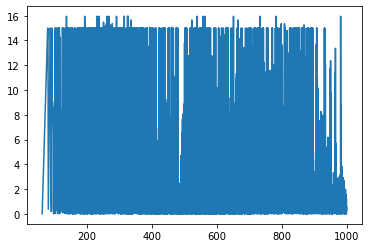

In [444]:
from sklearn.metrics import log_loss
from scipy.stats import chi2

def deviance(y, yp):
    return 2*log_loss(y, yp, normalize=False)

y=file.iloc[:,1]
model=LR_model
GOF=np.zeros((Data.shape[1],1))
for p in range(0,Data.shape[1]):
    X = Data_log.iloc[:,p].to_numpy()
    X=X.reshape(-1,1)
    yp=model.fit(X,y).predict_proba(X)
    yp_mean=np.zeros((len(Data),2))
    for i in range (0,len(Data)):
        yp_mean[i,0]=yp[:,0].mean()
        yp_mean[i,1]=yp[:,1].mean()
    res_deviance=deviance(y,yp)
    null_deviance=deviance(y,yp_mean)
    GOF[p]=null_deviance-res_deviance

chi2_pvals=np.zeros((Data.shape[1],1))
chi2_pvals=1-chi2.cdf(GOF , df=1)
chi2_pvals=np.where(chi2_pvals==0, 1e-15, chi2_pvals) 

plt.plot(mz,-np.log10(chi2_pvals))


idx_features2 = (-np.log10(chi2_pvals) > 2.5)
mz=mz.reshape(-1,1)
features_LR2=mz[idx_features2]
features_LR2.shape

In [446]:
np.savetxt('D:/BOX/Box Sync/RA/data/IMAGING/DESI/CRUK/pik3ca/Preprocessed/LR_features.txt',features_LR2,delimiter=',')

In [160]:
Data_r=np.zeros((len(Data),len(features_LR2)))
# Data_r=np.zeros((len(Data),len(features_ttest)))
for n in range (0,len(features_LR2)):
    Data_r[:,n]=file1[str(features_LR2[n])]
# for n in range (0,len(features_ttest)):
#     Data_r[:,n]=file.iloc[:,(features_ttest[n])]

# print(Data_r.shape)
model_r = LogisticRegression(solver='liblinear')
cvFold = logo.split(Data_log,file1.iloc[:,1],groups=file1['ID'])
cv_results3 = cross_val_score(model_r, Data_r, file1.iloc[:,1], cv=cvFold)
cm3 = calculate_cm(cv_results3,file1.iloc[:,1])
sen3 = (cm3[0,0])/(cm3[0,0]+cm3[0,1])*100
spec3 = (cm3[1,1])/(cm3[1,1]+cm3[1,0])*100
print('with LOOCV, classification accuracy with these features:\n')
print('confusion matrix = ')
print(cm3, '\n')
print('accuracy = ',cv_results3.mean()*100, '%','\n')
print('sensitivity = TP / (TP+FN) = ',sen3, '%','\n')
print('specificity = TN / (TN+FP) = ',spec3, '%','\n')

with LOOCV, classification accuracy with these features:

confusion matrix = 
[[ 44.  24.]
 [143. 338.]] 

accuracy =  69.36936936936937 % 

sensitivity = TP / (TP+FN) =  64.70588235294117 % 

specificity = TN / (TN+FP) =  70.27027027027027 % 



## Feature selection with LASSO

In [94]:
# snv transform to centre mean
from sklearn.preprocessing import StandardScaler
Data_snv=StandardScaler().fit_transform(Data)
# Data_snv=StandardScaler().transform(Data)
Data_snv.shape

(75, 2554)

In [114]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
lasso=LassoCV(max_iter=10000,tol=1e-3,n_alphas=1000,cv=10)
# lasso = Lasso(max_iter=2000,tol=1e-3,)
target=file['Label']
target=np.where(target=='WT', 0, target)
target=np.where(target=='PIK3CA', 1, target)
# target=np.where(target=='APC_KRAS_P53_control', 1, target)
# target=np.where(target=='APC_KRAS_P53_sim', 1, target) 
clf_LASSO=lasso.fit(Data_log,target)
clf_LASSO.score(Data_log,target)

# print(importance)
# importance.shape

0.9970997657349001

In [81]:
# from sklearn.model_selection import KFold
# from sklearn.model_selection import GridSearchCV

# lasso = Lasso(tol=1e-3, max_iter=10000)
# alphas = np.logspace(-4, -0.5, 30)
# tuned_parameters = [{'alpha': alphas}]

# clf = GridSearchCV(lasso, tuned_parameters, cv=5, refit=False)
# clf.fit(Data, target)
# scores = clf.cv_results_['mean_test_score']
# scores_std = clf.cv_results_['std_test_score']
# # cvFold_lasso = logo.split(Data,target,groups=tmp1['ID'])
# cv_results_LASSO = cross_val_score(lasso, Data, target, cv=5,scoring='accuracy')
# cv_results_LASSO.mean()

(112,)


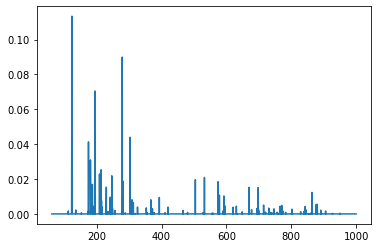

In [115]:
importance = np.abs(clf_LASSO.coef_)
selection=(importance != 0)
features_lasso=mz[selection]
# selection=importance[selection]
# idx_features2 = (-selection).argsort()
# importance[idx_features2]

print(features_lasso.shape)
plt.plot(mz,importance)
# np.savetxt('D:/BOX/Box Sync/RA/data/IMAGING/DESI/CRUK/pik3ca/Preprocessed/LASSO_features.txt',features_lasso,delimiter=',')

# Feature selection with univariate analysis

In [9]:
from bioinfokit import analys, visuz
from scipy import stats

# control=file['Label']!= "APC_sim"
class1=file['Label']== "green"
class2=file['Label']== "red"
# control=tmp1[class1]
green_data=Data[class1]
# APC=tmp1[class2]
red_data=Data[class2]
# APC_data

#Kruskal-Wallis test (non-parametric for multiple groups)

p_vals_KW=np.zeros(len(mz))
for i in range(len(mz)):
#     print(i)
    if (np.round(np.mean(green_data.iloc[:,i]),4))== (np.round(np.mean(red_data.iloc[:,i]),4)):
        p_vals_KW[i]=1
    else:
        dum1=stats.kruskal(green_data.iloc[:,i],red_data.iloc[:,i])
        dum2=dum1.pvalue
        p_vals_KW[i]=(dum2)        

In [17]:
#Mann-Whitney test (non-parametric binary problem)

p_vals_MW=np.zeros(len(mz))
for i in range(len(mz)):
#     print(i)
    if (np.round(np.mean(green_data.iloc[:,i]),4))== (np.round(np.mean(red_data.iloc[:,i]),4)):
        p_vals_MW[i]=1
    else:
        dum1=stats.mannwhitneyu(green_data.iloc[:,i],red_data.iloc[:,i])
        dum2=dum1.pvalue
        p_vals_MW[i]=(dum2)

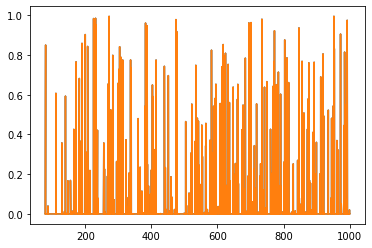

In [122]:
plt.plot(mz,p_vals_KW,mz,2*p_vals_MW)

# KW test = MW test for a two-way comparison~

In [10]:
#FDR correction

[rejected,correct_p]=statsmodels.stats.multitest.fdrcorrection(p_vals_KW, alpha=0.05, method='indep', is_sorted=False)

correct_p
# p_vals.shape

array([3.09499700e-010, 2.26030539e-010, 0.00000000e+000, ...,
       4.36505152e-043, 5.41799505e-005, 6.13373698e-273])

In [11]:
#fold changes calculation

green_mean=np.mean(green_data.iloc[:,:])
green_mean=np.where(green_mean==0, 1, green_mean) 
red_mean=np.mean(red_data.iloc[:,:])
red_mean=np.where(red_mean==0, 1, red_mean) 

fc=green_mean/red_mean
log2fc=np.log2(fc)
# plt.plot(mz,fc)
# plt.plot(mz,control_mean)
# plt.plot(mz,APC_mean)

In [12]:
# plot and save volcano plot
# mzlabel=np.zeros(len(mz))
mzlabel=[''] * len(mz)
for i in range(len(mz)):
    mzlabel[i]=str(mz[i])
# dum=np.vstack((correct_p,log2fc,mzlabel))
# dum=dum.transpose()

volcano_data=pd.DataFrame(index=range(0,len(mz)),columns=['pvals','fc','mz'])
volcano_data.iloc[:,0]=correct_p
volcano_data.iloc[:,1]=log2fc
volcano_data.iloc[:,2]=mzlabel
top30=volcano_data['pvals'].sort_values(ascending=True)
top30 = top30[0:30].index
# labels=mz[top30]
labels=np.array2string(mz[top30],separator=',',precision=12)
# print(labels)


# mz_label
# visuz.gene_exp.volcano(df=volcano_data, lfc='fc', pv='pvals')

visuz.gene_exp.volcano(df=volcano_data, lfc='fc', pv='pvals',geneid="mz",genenames=labels,
                       lfc_thr=2,pv_thr=1e-100,sign_line=True)
# check=volcano_data['mz']=='168.8583166826'
# mz[check]

D:\anaconda3\lib\site-packages\pandas\core\series.py:679: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [16]:
# select and save spectral features according volcano plot thresholds
condition=(volcano_data['pvals'] <= 1e-200) & (abs(volcano_data['fc']) >= 2.5)
features=mz[condition]
# print(volcano_data[check])
print(features.shape)
# np.savetxt('D:/BOX/Box Sync/RA/data/IMAGING/DESI/CRUK/project B/features_volcano_low_thresh.txt',features,delimiter=',')
# # print(condition)
# features


(847,)


# Box plotting

In [27]:
frames=[file1,file2,file3,file4]
box_data= pd.concat(frames)

group_label = list(box_data.columns)

index1= np.argmin(abs(mz-306.076))
index2= np.argmin(abs(mz-611.1441))
label1= group_label[index1+2]
label2= group_label[index2+2]

ion1 = box_data[label1]
ion1 = ion1/np.median(ion1)
ion2 = box_data[label2]
ion2 = ion2/np.median(ion2)
ion2 = np.where(ion2==0, 1, ion2)
ratio = ion1/ion2
# ratio = ratio.fillna(0)
box_data['ratio'] = ratio
box_data

,ID,Label,78.9590139215418,79.9573703757595,87.0088933348069,88.0405573905797,96.9653525684107,102.056320139865,106.981111507431,108.90225217827,...,995.623552200367,996.097969772705,996.639219261308,997.551513756936,997.639747546673,998.105053478688,998.555700268595,998.655290296959,999.538511691367,ratio
0,1,APC_control,344,600,109,0,150,223,0,118,...,0,0,0,0,164,0,0,0,0,0.839984
1,2,APC_control,155,369,0,0,376,230,0,79,...,0,0,142,0,0,0,0,0,0,0.965740
2,3,APC_control,328,674,0,185,302,129,0,133,...,0,0,0,0,0,0,0,113,0,0.672310
3,4,APC_control,399,475,0,0,406,141,0,123,...,0,0,137,0,0,0,0,0,0,0.875453
4,5,APC_control,534,499,168,0,504,307,0,208,...,0,0,171,0,0,0,0,0,0,0.914954
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
482,483,APC_KRAS_control,268,408,0,0,367,203,0,88,...,0,0,0,0,0,0,0,0,0,0.829946
483,484,APC_KRAS_control,711,1134,0,142,448,145,109,0,...,0,0,0,0,0,0,0,0,0,2.037082
484,485,APC_KRAS_control,113,193,0,0,100,33,0,86,...,0,0,0,0,0,0,0,0,0,0.249899
485,486,APC_KRAS_control,512,772,0,92,386,364,0,132,...,0,0,0,0,0,0,0,0,0,1.101444


(0.0, 4.0)

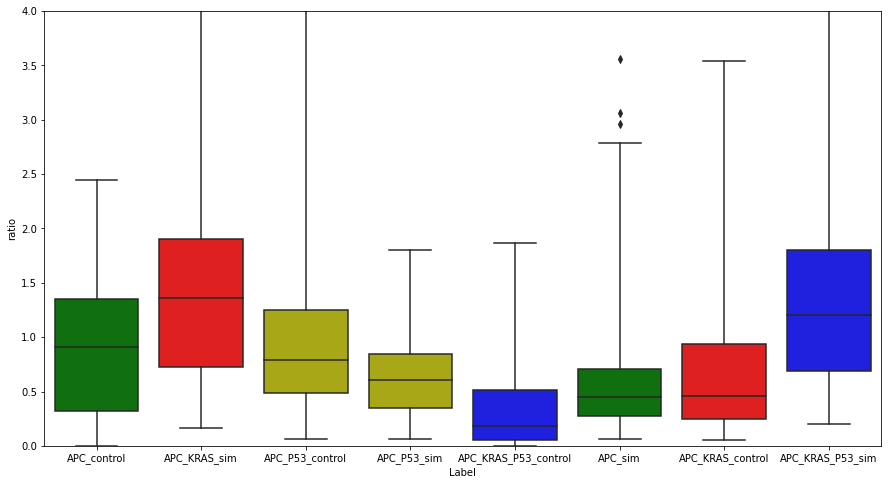

In [28]:
feature='ratio'
plt.figure(figsize=(15,8))
# colors = {"red": "r", "green": "g"}
colors = {"APC_control": "g", "APC_sim": "g","APC_KRAS_control": "r", "APC_KRAS_sim": "r",
         "APC_P53_control": "y", "APC_P53_sim": "y","APC_KRAS_P53_control": "b", "APC_KRAS_P53_sim": "b"}
sns.boxplot(x="Label", y=feature, data=box_data, palette=colors, whis=5)
# file[feature].mean()
plt.ylim(0, 4)